In [20]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


def generate_iphone_lifecycle_data():
    dates = pd.date_range(start="2020-01-01", end="2024-01-01", freq="ME")
    df = pd.DataFrame({'Date': dates})

    launch_schedule = {
        'iPhone_12': pd.Timestamp('2020-10-31'),
        'iPhone_13': pd.Timestamp('2021-09-30'),
        'iPhone_14': pd.Timestamp('2022-09-30')
    }

    def create_sales_curve(product_name, launch_date, peak_sales=100_000):
        sales = []
        months_since_launch = 0

        for date in df['Date']:
            if date < launch_date:
                sales.append(0)
            else: 
                months_since_launch+=1

                if months_since_launch<=3:
                    # Logarithmic growth for first 3 months
                    base_sales = peak_sales * (0.5+(0.5*(months_since_launch/3)))
                else:
                    # Natural decay of intereset over time (Bass model tail)
                    decay_rate = 0.02 # 2% drop per month naturally
                    base_sales = peak_sales *((1-decay_rate)**(months_since_launch-3))

                if date.month in [11,12]:
                    base_sales *=1.3

                # Add some random noise (mmarket fluctuation)
                noise = np.random.normal(0, peak_sales * 0.05)
                sales.append(max(0, int(base_sales + noise)))
        return np.array(sales)

    df['iPhone_12_Sales'] = create_sales_curve('iPhone_12', launch_schedule['iPhone_12'], 120000)
    df['iPhone_13_Sales'] = create_sales_curve('iPhone_13', launch_schedule['iPhone_13'], 130000)
    df['iPhone_14_Sales'] = create_sales_curve('iPhone_14', launch_schedule['iPhone_14'], 135000)



    def apply_cannibalization(victim_col, cannibal_launch_date):
        adjusted_sales = []
        for date, sales in zip(df['Date'], df[victim_col]):
            if date>= cannibal_launch_date:
                # The Cannibalization Factor:
                # Sales crash to 40% of their natural volume inmmmediately after successor launch
                # Then they decay extra fast (0.85 multiplier) every month thereafter
                months_post_cannibal = (date.year - cannibal_launch_date.year)*12 + (date.month - cannibal_launch_date.month)
                cannibal_decay = 0.4 *(0.85**months_post_cannibal)
                adjusted_sales.append(int(sales*cannibal_decay))
            else:
                adjusted_sales.append(sales)

        return adjusted_sales


    df['iPhone_12_Sales'] = apply_cannibalization('iPhone_12_Sales', launch_schedule['iPhone_13'])
    df['iPhone_13_Sales'] = apply_cannibalization('iPhone_13_Sales', launch_schedule['iPhone_14'])

    return df

In [21]:
df = generate_iphone_lifecycle_data()
print(df.shape)

(48, 4)


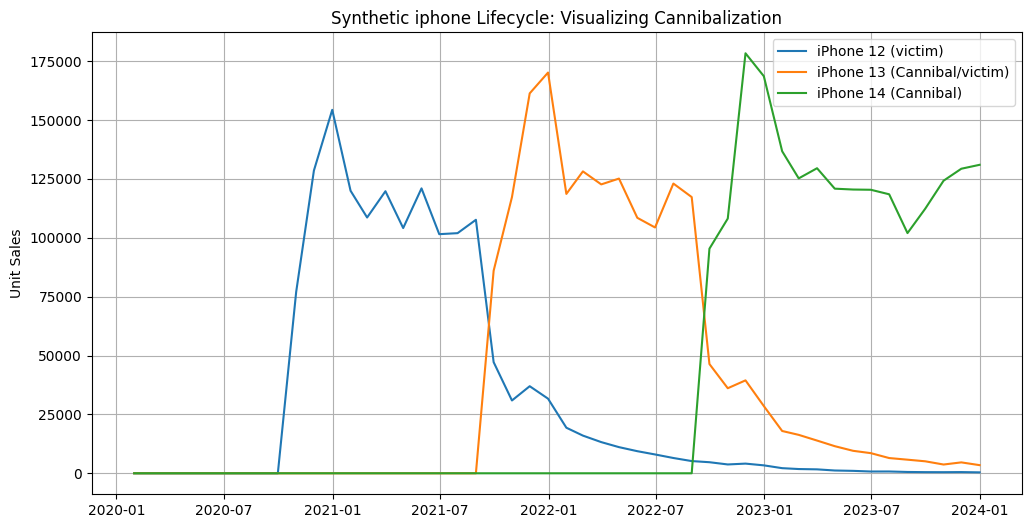

In [25]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(df['Date'], df['iPhone_12_Sales'], label='iPhone 12 (victim)')
ax.plot(df['Date'], df['iPhone_13_Sales'], label='iPhone 13 (Cannibal/victim)')
ax.plot(df['Date'], df['iPhone_14_Sales'], label='iPhone 14 (Cannibal)')
ax.set_title("Synthetic iphone Lifecycle: Visualizing Cannibalization")
ax.set_ylabel('Unit Sales')
ax.grid()
_ = ax.legend()


## Model Equations:

In [358]:
# The model:
def F(x, p, q):
    """
    x = t - tau_i
    p, q have units of time
    Vectorized in x (scalar or numpy array).
    F(x)=0 for x<0.
    """
    # x = np.asarray(x)
    a = q / p
    b = q + p
    out = np.zeros_like(x, dtype=float)
    mask = x >= 0
    xm = x[mask]
    out[mask] = (1.0 - np.exp(-b * xm)) / (1.0 + a * np.exp(-b * xm))
    return out

def G_kn(k, n, t, p, q, tau, m, F):
    prod = 1.0
    for i in range(k-1, n):
        prod *= F(t - tau[i], p, q)
    return m[n-1] * prod


def S_n(n, t, theta, F, N):
    """
    tau: array dim M (number of devices)
    m: array dim M (number of devices)
    """
    p, q, tau, m = unpack_theta(theta, N=N)
    assert (n <= len(tau)) and (len(tau)==len(m)), "Check n <= lent(tau) and len(tau)==len(m)"
    Fn = F(t - tau[n-1], p, q)
    factor = 1.0 - Fn

    total = 0.0
    for k in range(1, n+1):
        total += G_kn(k, n, t, p, q, tau, m, F) * factor
    return total

def pack_theta(p, q, tau, m):
    """
    p, q : scalars
    tau  : sequence of length N
    m    : sequence of length N
    """
    return np.concatenate((
        np.array([p, q], dtype=float),
        np.asarray(tau, dtype=float),
        np.asarray(m, dtype=float),
    ))

def unpack_theta(theta, N):
    p, q = theta[:2]
    tau = theta[2:2+N].tolist()
    m   = theta[2+N:2+2*N].tolist()
    return p, q, tau, m

In [370]:
N = 3

t = np.arange(48)
theta0 = pack_theta(p=0.2, q=0.3, tau=[9, 12, 25], m=[1000, 1000, 1200])
p0, q0, tau0, m0 = unpack_theta(theta0, N=N)

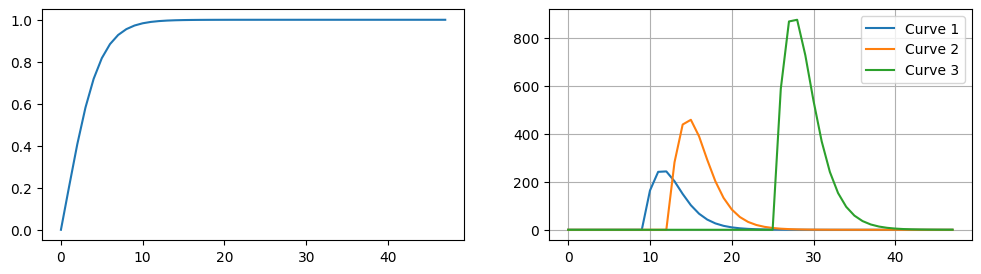

In [376]:
fig,axs = plt.subplots(nrows=1, ncols=2, figsize=(12,3))
axs = axs.flatten()
f = F(t, p0, q0)

axs[0].plot(t, f)
axs[1].plot(t, S_n(1, t, theta0, F, N), label="Curve 1")
axs[1].plot(t, S_n(2, t, theta0, F, N), label="Curve 2")
axs[1].plot(t, S_n(3, t, theta0, F, N), label="Curve 3")
axs[1].grid()
_=axs[1].legend()

In [298]:
# Estimates equations jointly: 
def residuals_1D(theta, t, S_obs, N):
    """
    theta = [p, q, tau_1,...,tau_N, m_1,...,m_N]
    """
    p, q = theta[:2]
    tau = theta[2:2+N]
    m   = theta[2+N:2+2*N]

    res = []
    diff = np.zeros(len(t))
    for n in range(1, N+1):
        Sn_hat = S_n(n, t, theta, F, N)
        diff += (Sn_hat - S_obs.iloc[:, n])**2


    return np.sqrt(diff)

def residuals(theta, t, S_obs, N):
    """
    theta = [p, q, tau_1,...,tau_N, m_1,...,m_N]
    """
    p, q = theta[:2]
    tau = theta[2:2+N]
    m   = theta[2+N:2+2*N]

    res = []
    diff = np.zeros(len(t))
    for n in range(1, N+1):
        Sn_hat = S_n(n, t, theta, F, N)
        res.append(Sn_hat - S_obs.iloc[:, n])

    return np.array(res).reshape(len(t), N).ravel()


In [357]:

def theta_to_str(theta):
    p, q = theta[:2]
    tau = theta[2:2+N]
    m   = theta[2+N:2+2*N]
    tau_str = np.array2string(tau, precision=3, separator=", ")
    m_str   = np.array2string(m, precision=3, separator=", ")
    return f"""p, q: {p:.3f}, {q:.3f} ; tau: {tau_str} ; m: {m_str}"""
    
def print_theta(theta, s=""):
    p, q = theta[:2]
    tau = theta[2:2+N]
    m   = theta[2+N:2+2*N]
    tau_str = np.array2string(tau, precision=3, separator=", ")
    m_str   = np.array2string(m, precision=3, separator=", ")
    
    print(s)
    print(f"""
      p, q: {p:.3f}, {q:.3f}
    tau: {tau_str},
      m: {m_str}
    """)

# t = df.index.to_numpy()
# t

In [300]:
# N=3
# theta = pack_theta(p=0.2, q=0.5, tau = [9, 12, 18], m = [400, 700, 100])
# n=1
# Sn_hat = S_n(n, t, theta, F, N)

# plt.plot(t, Sn_hat)
# n=2
# Sn_hat = S_n(n, t, tau, m, p, q, F)
# plt.plot(t, Sn_hat)

In [312]:
def make_bounds(N):
    # theta = [p, q, tau_1..tau_N, m_1..m_N]
    lower = np.zeros(2 + 2*N)

    # p, q > 0
    lower[0] = 1e-8
    lower[1] = 1e-8

    # tau_i > 0
    lower[2:2+N] = 0 #1e-8

    # m_n > 0 
    lower[2+N:] = 1e-8

    upper = np.full(2 + 2*N, np.inf)
    return lower, upper

In [301]:
df.max()

Date               2023-12-31 00:00:00
iPhone_12_Sales                 154335
iPhone_13_Sales                 170168
iPhone_14_Sales                 178352
dtype: object

In [328]:
from scipy.optimize import least_squares

N = 3
# initial guess
theta0 = pack_theta(p=0.2, q=0.5, tau = [9, 12, 18], m = [150_000, 150_000, 150_000])
print_theta(theta0, "Reasonable initial guess:")


lb, ub = make_bounds(N)
res1 = least_squares(
    residuals,
    theta0,
    args=(t, df, N),
    bounds=(lb, ub),
    # loss="huber"
)

theta_1 = res1.x
u_hat = res1.fun

print_theta(theta_1, "Fitted values:")

Reasonable initial guess:

      p, q: 0.200, 0.500
    tau: [ 9., 12., 18.],
      m: [150000., 150000., 150000.]
    
Fitted values:

      p, q: 0.155, 0.000
    tau: [ 7.745, 18.82 , 31.076],
      m: [517270.59 , 306008.174, 238293.914]
    


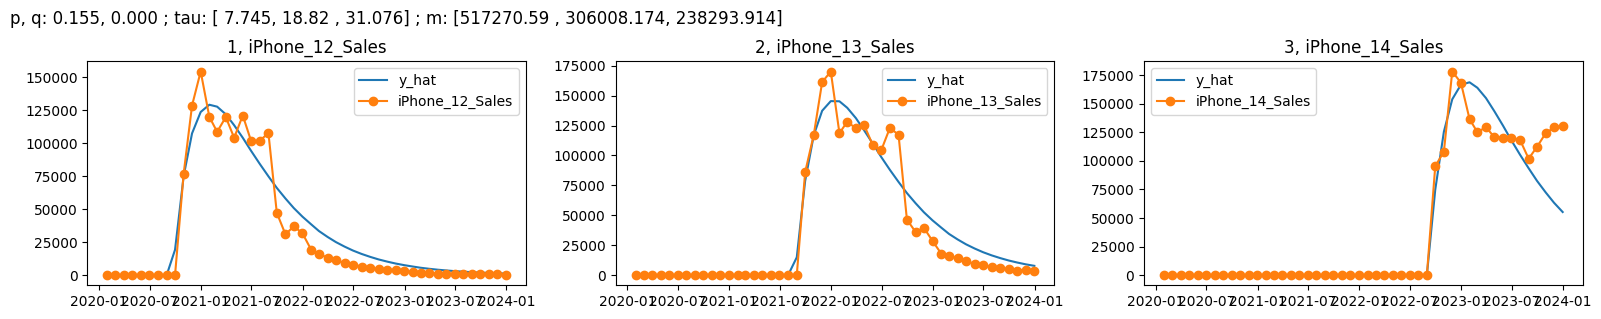

In [348]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(16,3))
axs = axs.flatten()

fig.text(s=theta_to_str(theta_1),x=0,y=1, fontsize=12)
for c in range(1,N+1):
    ax=axs[c-1]
    y_hat_1 = S_n(c, t, theta_1, F, N)
    date = df["Date"]
    ax.plot(date, y_hat_1, label="y_hat")
    ax.plot(date, df.iloc[:,c], label=df.columns[c], marker="o")
    ax.set_title(f"{c}, {df.columns[c]}")
    ax.legend()
    
fig.tight_layout()

In [339]:
def weighted_residuals(theta, t, S_obs, N, W):
    r = residuals(theta, t, S_obs, N)
    R = r.reshape(len(t), N)

    L = np.linalg.cholesky(W)
    Rw = R @ L.T

    return Rw.ravel()

T = len(t)
U = u_hat.reshape(T, N)   # each column = equation n
Sigma = np.cov(U, rowvar=False)
W = np.linalg.inv(Sigma)
    
res3 = least_squares(
    weighted_residuals,
    theta_1,
    args=(t, S_obs, N, W)
)

theta_3sls = res3.x
print_theta(theta_3sls, "Fitted params using Generalized least square:")

Fitted params using Generalized least square:

      p, q: 0.131, 0.035
    tau: [ 7.598, 18.865, 31.146],
      m: [475683.463, 291356.215, 222343.881]
    


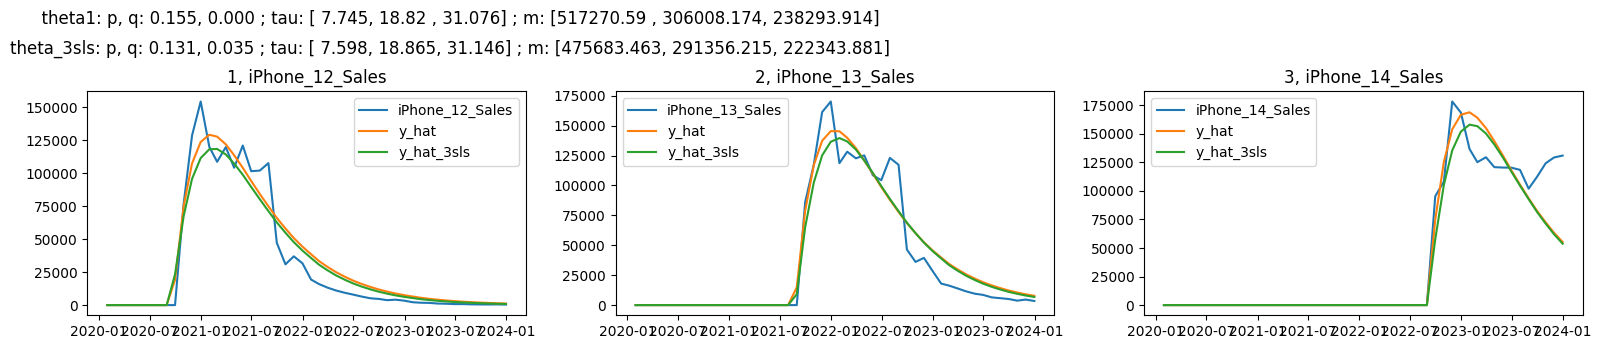

In [356]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(16,3))
axs = axs.flatten()

# p, q, tau, m = unpack_theta(theta_1, N)
fig.text(x=0, y=1.1, fontsize=12, s="      theta1: "+theta_to_str(theta_1))
fig.text(x=0, y=1, fontsize=12,   s="theta_3sls: "+theta_to_str(theta_3sls))
for c in range(1,N+1):
    ax=axs[c-1]
    y_hat_1 = S_n(c, t, theta_1, F, N)
    y_hat_3sls = S_n(c, t, theta_3sls, F, N)
    date = df["Date"]
    ax.plot(date, df.iloc[:,c], label=df.columns[c])#, marker="o")
    ax.plot(date, y_hat_1, label="y_hat")
    ax.plot(date, y_hat_3sls, label="y_hat_3sls")
    
    ax.set_title(f"{c}, {df.columns[c]}")
    ax.legend()
    
fig.tight_layout()